# Utilization Prediction

## a) Business Case

During the descriptives task, we defined three KPIs:

1) Utilization rate
2) Energy delivered per hour
3) Rate of registered user sessions

The business case behind these KPIs is defined as:

<br><br>
<center>
  <b style="font-size: 1.3em;">
    The prediction model enables the site operator to offer dynamic pricing to registered users to maximize revenue and energy throughput while smoothing demand.
  </b>
</center>
<br><br>

The model predicts the hourly utilization of a given site. This information can be used to offer dynamic pricing models: when utilization and energy delivered are low, prices can be lowered to encourage usage. Notifications can be sent to registered users, e.g. through an app, to increase engagement, improve site utilization and maximize energy throughput.


## b) Prediction Model

## Load Dataframes and inspect data

In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
import holidays
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

with open(data_path + "relevant_weather_data_prepared.pkl", "rb") as f:
    relevant_weather_data = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")
print(f"  relevant_weather_data shape: {relevant_weather_data.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)
  relevant_weather_data shape: (26187, 9)


We choose site 1 for this task

In [ ]:
print(merged_df.siteID.unique())
print(merged_df.stationID.dtype)
df_site_1 = merged_df[merged_df['siteID'] == '1']
df_site_1 = df_site_1.sort_values(by='connectionTime', ascending=True)

['1' '2']
object


In [ ]:
mask = df['charging_duration'] == df['session_duration']
anzahl = df[mask].shape[0]
print(f"Anzahl der Sitzungen, bei denen die Ladedauer gleich der Sitzungsdauer ist: {anzahl}")

Anzahl der Sitzungen, bei denen die Ladedauer gleich der Sitzungsdauer ist: 8479


In [ ]:
print(df_site_1['stationID'].nunique())

52


## Data Processing: Create hourly data of sessions

In [ ]:
def make_site1_hourly_features(df,
                               conn_col='connectionTime',
                               disc_col='disconnectTime',
                               station_col='stationID'):
    df = df.copy()
    df[conn_col] = pd.to_datetime(df[conn_col], errors='coerce')
    df[disc_col] = pd.to_datetime(df[disc_col], errors='coerce')

    n_stations = df[station_col].nunique()

    def row_hour_contrib(row):
        start = row[conn_col]
        end = row[disc_col]
        if pd.isna(start) or pd.isna(end) or end <= start:
            return []

        hours = pd.date_range(
            start=start.floor('h'),
            end=(end - pd.Timedelta(seconds=1)).floor('h'),
            freq='h'
        )

        out = []
        for h in hours:
            h_start = max(start, h)
            h_end = min(end, h + pd.Timedelta(hours=1))
            minutes = (h_end - h_start).total_seconds() / 60.0
            if minutes > 0:
                out.append({
                    'datetime': h,
                    'minutes': minutes,
                    'kWhDelivered': row['kWhDelivered'],
                    'userID': row['userID'],
                    'siteID': row[station_col],
                    'is_registered': row['isRegisteredUser'],
                    'session_duration': row['session_duration'],
                    'charging_duration': row['charging_duration']

                })
        return out

    contrib = df.apply(row_hour_contrib, axis=1)
    tmp = pd.DataFrame([item for lst in contrib for item in lst])

    if tmp.empty:
        return pd.DataFrame(columns=[
            'datetime', 'hourly_utilization_minutes', 'hourly_utilization'
        ]).set_index('datetime')

    # Stundenaggregation für Nutzung + zusätzliche Features
    hourly = (
        tmp.groupby('datetime')
            .agg(
                hourly_utilization_minutes=('minutes', 'sum'),
                energy_kwh_hour=('kWhDelivered', 'sum'),
                avg_kwh_per_session=('kWhDelivered', 'mean'),
                avg_session_duration=('session_duration', 'mean'),
                avg_charging_duration=('charging_duration', 'mean'),
                n_sessions=('userID', 'nunique'),
                n_registered_sessions=('is_registered', 'sum')
            )
    )

    hourly['hourly_utilization'] = (
        hourly['hourly_utilization_minutes'] / (n_stations * 60.0)
    ).clip(0, 1)

    return hourly

    

In [ ]:
df_site_1_features = make_site1_hourly_features(df_site_1, 'connectionTime', 'disconnectTime')
df_site_1_features.head()

,hourly_utilization_minutes,energy_kwh_hour,avg_kwh_per_session,avg_session_duration,avg_charging_duration,n_sessions,n_registered_sessions,hourly_utilization
datetime,,,,,,,,
2018-09-05 04:00:00-07:00,107.633333,16.697,8.348500,5.552083,5.552083,2,1,0.034498
2018-09-05 05:00:00-07:00,153.250000,34.751,8.687750,8.177778,8.177778,4,3,0.049119
2018-09-05 06:00:00-07:00,469.800000,110.399,10.036273,8.564394,8.564394,10,9,0.150577
2018-09-05 07:00:00-07:00,874.300000,158.350,9.896875,8.464219,8.464219,10,9,0.280224
2018-09-05 08:00:00-07:00,900.000000,151.236,10.082400,8.827519,8.827519,9,8,0.288462


In [ ]:
df_site_1_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16123 entries, 2018-09-05 04:00:00-07:00 to 2021-09-14 07:00:00-07:00
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hourly_utilization_minutes  16123 non-null  float64
 1   energy_kwh_hour             16123 non-null  float64
 2   avg_kwh_per_session         16123 non-null  float64
 3   avg_session_duration        16123 non-null  float64
 4   avg_charging_duration       16123 non-null  float64
 5   n_sessions                  16123 non-null  int64  
 6   n_registered_sessions       16123 non-null  int64  
 7   hourly_utilization          16123 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 1.1 MB


## Feature Engineering

### Add before covid boolean

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify the Gap
# We calculate the time difference between each row
time_diffs = df_site_1_features.index.to_series().diff()

# The largest gap will be our COVID period
gap_end = time_diffs.idxmax()
gap_start = df_site_1_features.index[df_site_1_features.index.get_loc(gap_end) - 1]

print(f"Gap detected between: {gap_start} and {gap_end}")
print(f"Total gap duration: {gap_end - gap_start}")

# 2. Add 'before_covid' column
# 1 if before the gap start, 0 if after (or at) the gap end
df_site_1_features['before_covid'] = (df_site_1_features.index <= gap_start).astype(int)

# Verify the split
print("\nValue counts for 'before_covid':")
print(df_site_1_features['before_covid'].value_counts())

Gap detected between: 2020-08-03 21:00:00-07:00 and 2020-11-18 12:00:00-08:00
Total gap duration: 106 days 16:00:00

Value counts for 'before_covid':
before_covid
1    11339
0     4784
Name: count, dtype: int64


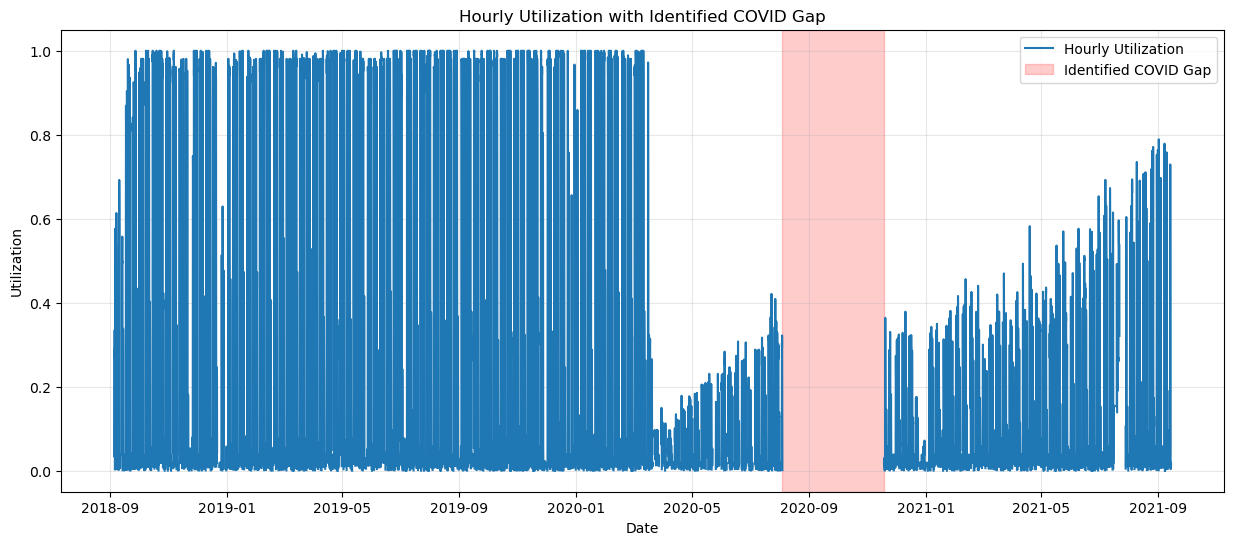

In [ ]:
# Create a continuous hourly range from the very start to the very end
full_range = pd.date_range(start=df_site_1_features.index.min(), 
                           end=df_site_1_features.index.max(), 
                           freq='h')

# Reindex to show where the gaps are (will fill missing hours with NaN)
df_reindexed = df_site_1_features.reindex(full_range)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_reindexed.index, df_reindexed['hourly_utilization'], label='Hourly Utilization', color='tab:blue')

# Highlight the gap
plt.axvspan(gap_start, gap_end, color='red', alpha=0.2, label='Identified COVID Gap')

plt.title('Hourly Utilization with Identified COVID Gap')
plt.xlabel('Date')
plt.ylabel('Utilization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Calculate the time difference between consecutive rows
# this helps find the largest gap in the Datetime Index
time_diffs = df_site_1_features.index.to_series().diff()

# 2. Identify the timestamp where the data resumes after the gap
gap_end_timestamp = time_diffs.idxmax()

print(f"Data resumes after gap at: {gap_end_timestamp}")

# 3. Create the 'before_covid' column
# It assigns 1 to all timestamps before the gap, and 0 to all those after
df_site_1_features['before_covid'] = (df_site_1_features.index < gap_end_timestamp).astype(int)
print(df_site_1_features['before_covid'].value_counts())

Data resumes after gap at: 2020-11-18 12:00:00-08:00
before_covid
1    11339
0     4784
Name: count, dtype: int64


### Add holiday, month, day of week, hour of day features

We add a feature for holidays as this  influence the utilization due to the fact that employees do not work at this and university is also closed there. Additionally we add the already know time features from the session dataset.

In [ ]:
US_holidays = holidays.US(state='CA')

# Ensure index is datetime
df_site_1_features.index = pd.to_datetime(df_site_1_features.index)

df_site_1_features['is_holiday'] = df_site_1_features.index.to_series().apply(lambda dt: dt in US_holidays)
df_site_1_features['holiday_name'] = df_site_1_features.index.to_series().apply(lambda dt: US_holidays.get(dt) if dt in US_holidays else '')

#Add time features based on the index
df_site_1_features['year'] = df_site_1_features.index.year
df_site_1_features['month'] = df_site_1_features.index.month
df_site_1_features['day'] = df_site_1_features.index.day
df_site_1_features['hour'] = df_site_1_features.index.hour
df_site_1_features['dayofweek'] = df_site_1_features.index.dayofweek
df_site_1_features['is_weekend'] = df_site_1_features['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
    
df_site_1_features['season'] = df_site_1_features['month'].apply(get_season)

In [ ]:
df_site_1_features['util_last_hour_flag'] = df_site_1_features['hourly_utilization'].shift(1)

df_site_1_features['util_prev_day_flag'] = df_site_1_features['hourly_utilization'].shift(24)

In [ ]:
#lag_cols = ['util_last_hour_flag', 'util_prev_day_flag']
#df_site_1_features = df_site_1_features.dropna(subset=lag_cols)

## Feature Selection

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_site_1_features.copy()
df_plot['day_name'] = df_plot.index.day_name()
df_plot['hour'] = df_plot.index.hour
df_plot['month_name'] = df_plot.index.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

### Averga Utilization by day of Week

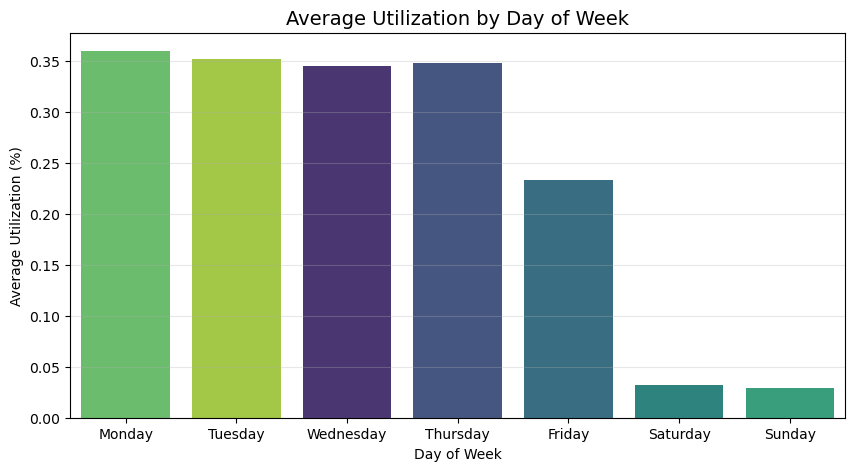

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_plot, 
    x='day_name', 
    y='hourly_utilization', 
    order=day_order, 
    palette='viridis', 
    hue='day_name',
    legend=False,
    errorbar=None
)
plt.title('Average Utilization by Day of Week', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Day of Week')
plt.grid(axis='y', alpha=0.3)
plt.show()

The data shows big contrast between high week utilization and near zero weekend usage. Therefore, we asssume day of the week to be a useful predictor of utilization.

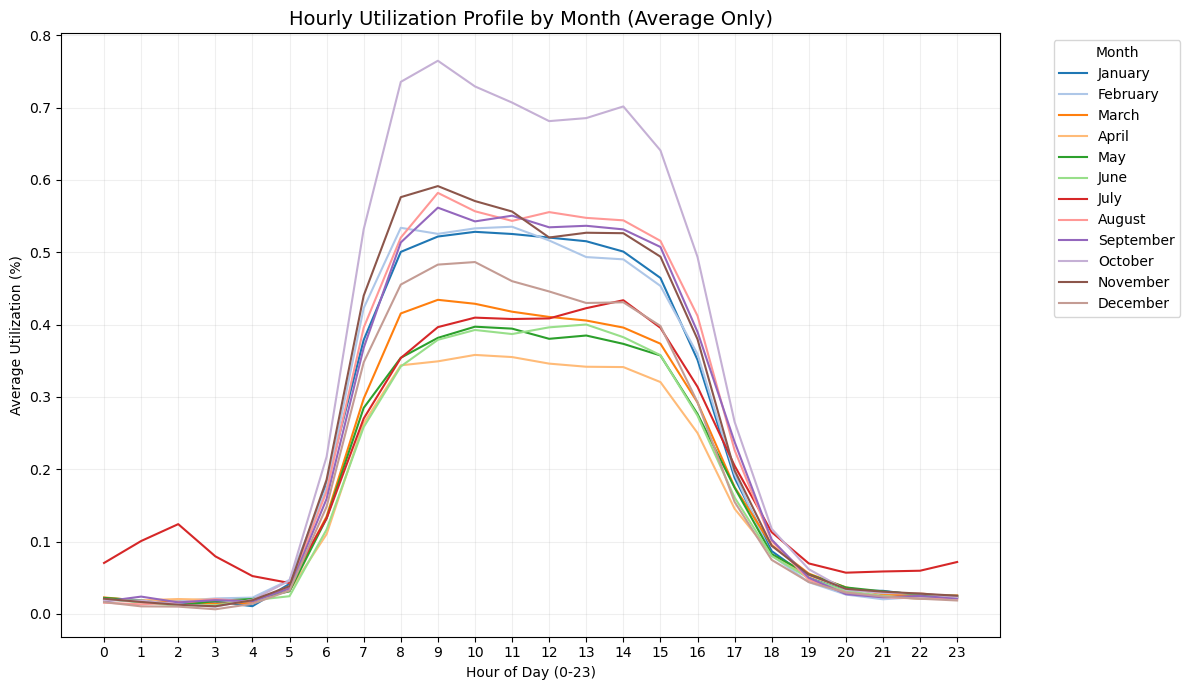

In [ ]:
plt.figure(figsize=(12, 7))

sns.lineplot(data=df_plot, x='hour', y='hourly_utilization', 
             hue='month_name', hue_order=month_order, 
             palette='tab20', errorbar=None)

plt.title('Hourly Utilization Profile by Month (Average Only)', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Hour of Day (0-23)')
plt.xticks(range(0, 24))
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

As shown in the Figure above, the average utilization varies significantly at different times of the day. This temporal variation highlights the importance of including a hour of the day feature in the model, enabling the model to learn patterns based on the time of the day. Similarly, the data displays seasonal fluctuations and across different months. This monthly variation necessitates the inclusion of a month feature to allow the model to capture recurring seasonal patterns.

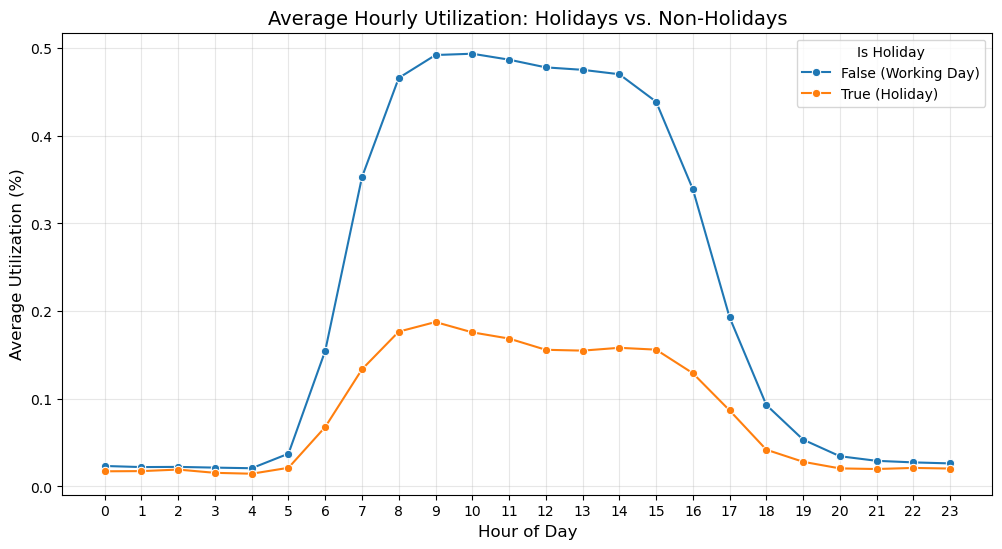

In [ ]:
# Visualize average utilization: Holidays vs. Non-Holidays
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_site_1_features, 
    x='hour', 
    y='hourly_utilization', 
    hue='is_holiday', 
    marker='o',
    errorbar=None  # Shows the mean only;
)

plt.title('Average Hourly Utilization: Holidays vs. Non-Holidays', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Utilization (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

# Update legend for clarity
plt.legend(title='Is Holiday', labels=['False (Working Day)', 'True (Holiday)'])
plt.show()

As illustrated in the figure above, the average utilization on public holidays is much lower compared to working days.  This necessitates the inclusion of an is_holiday feature, allowing the model to differentiate between these two modes of behavior and avoid over estimating demand during public holidays.

## Training Test Validation Split on selected features

In [ ]:
X = df_site_1_features[['hour', 'dayofweek', 'month', 'before_covid']]#, 'util_last_hour_flag', 'util_prev_day_flag']]
y = df_site_1_features['hourly_utilization']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
x_train, x_hold, y_train, y_hold = train_test_split(x_train, y_train, test_size=(0.2/0.7), random_state=1)

print(len(x_train), len(x_hold), len(x_test))

8061 3225 4837


## Modeling

### Regression Code

We run different models of polynomial regression with ridge and lasso regularization to predict charging session duration. Our approach includes:

1. **Polynomial Features**: We test polynomial degrees from 1 to 7 to capture non-linear relationships the features from the session data set

2. **Model Types**:
   - **Linear Regression**: Baseline model without regularization
   - **Ridge Regression**: L2 regularization to penalize large coefficients and reduce overfitting
   - **Lasso Regression**: L1 regularization to perform feature selection while reducing overfitting

3. **Regularization Strength**: For Ridge and Lasso, we test alpha values [0.01, 0.1, 1, 10] to find optimal regularization strength. Higher alpha values increase the penalty.

4. **Cross-validation Approach**: We train on the training set and evaluate on the holdout set using the R² metric to prevent overfitting and select the best model.

The goal is to find the model that best generalizes to unseen data by balancing model complexity with prediction accuracy, as measured by the R² score which indicates the proportion of variance explained by the model.

In [ ]:
degrees = range(1, 8) #TODO später wieder höher stellen, dauert sonst zu lange in der ausführung
alphas = [0.01, 0.1, 1, 10]
models = ["linear", "Ridge", "Lasso"]
results = []

In [ ]:
def run_models(models, degrees, alphas, 
               x_train, x_hold, y_train, y_hold):
    rows = []  # list of dicts, reusable each call

    for model in models:
        for degree in degrees:
            # create polynomial features
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_train_poly = poly.fit_transform(x_train)
            X_hold_poly = poly.transform(x_hold)

            # standardize
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_poly)
            X_hold_scaled = scaler.transform(X_hold_poly)

            if model in ["Ridge", "Lasso"]:
                for alpha in alphas:
                    if model == "Ridge":
                        reg = Ridge(alpha=alpha)
                    else:
                        reg = Lasso(alpha=alpha, max_iter=10000)

                    reg.fit(X_train_scaled, y_train)

                    y_hold_pred = reg.predict(X_hold_scaled)
                    mse_val = mean_squared_error(y_hold, y_hold_pred)
                    r2_val = r2_score(y_hold, y_hold_pred)

                    rows.append({
                        "model": model,
                        "degree": degree,
                        "alpha": alpha,
                        "mse": mse_val,
                        "r2": r2_val,
                        "poly": poly,
                        "scaler": scaler,
                        "reg": reg
                    })
            else:
                reg = LinearRegression()
                reg.fit(X_train_scaled, y_train)
                y_hold_pred = reg.predict(X_hold_scaled)
                mse_val = mean_squared_error(y_hold, y_hold_pred)

                rows.append({
                    "model": model,
                    "degree": degree,
                    "alpha": None,
                    "mse": mse_val,
                    "poly": poly,
                    "scaler": scaler,
                    "reg": reg
                })

    return pd.DataFrame(rows)


In [ ]:
results = run_models(models, degrees, alphas, x_train, x_hold, y_train, y_hold)
best_idx = results["r2"].idxmax()
best_model = results.loc[best_idx]

print(best_model)

model                                                Ridge
degree                                                   7
alpha                                                 0.01
mse                                               0.034968
poly      PolynomialFeatures(degree=7, include_bias=False)
scaler                                    StandardScaler()
reg                                      Ridge(alpha=0.01)
r2                                                0.710697
Name: 31, dtype: object


We see that the best model uses **Ridge regularization**, has a **polynomial degree of 7** with an alpha of **0.01**. This configuration indicates that:

- **Ridge Regression** was more effective than Lasso, suggesting that all features contribute meaningfully to predicting charging duration rather than needing feature selection.
- **Polynomial degree 7** captures complex non-linear relationships between the features of the session dataset, suggesting that the interaction between multiple session factors is important.
- **Low alpha (0.01)** means minimal regularization penalty was needed, indicating the model doesn't suffer from severe overfitting with the polynomial features.

The model's performance on the holdout set yields an **R² score of 0.71**, meaning it explains 71% of the variance in utilzation of the charging hubs. This is a solid result indicating good predictive power while leaving some variance unexplained, which could be attributed to factors not captured in the session data alone(e.g. weather, ...)

In [ ]:
best_poly = best_model['poly']
best_scaler = best_model['scaler']
best_reg = best_model['reg']

X_test_poly = best_poly.transform(x_test)
X_test_scaled = best_scaler.transform(X_test_poly)

y_test_pred = best_reg.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Test MSE: {mse_test}")
print(f"Test R2: {r2_test}")


Test MSE: 0.036492192244002006
Test R2: 0.6940802812663008


On the test set, we achieve an **R² score of 0.69**, which is slightly lower than the holdout set performance (0.71). This modest decrease is expected and indicates good generalization—the model doesn't show signs of significant overfitting. The test R² of 0.69 means the model explains 69% of the variance in charging hub utilization on completely unseen data. The 2-point difference between holdout and test performance suggests the model is stable and reliable for making predictions on new data.

### Decision Tree Code

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# 1. Initialize a basic tree
regr = DecisionTreeRegressor(random_state=42)

# 2. Get the pruning path
path = regr.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
# 3. Use these alphas in Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'ccp_alpha': ccp_alphas[::5], # Subsample alphas to speed up search
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)
grid_search.fit(x_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'ccp_alpha': array([0.0000...90920551e-03]), 'min_samples_leaf': [5, 10, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


<Axes: title={'center': 'Feature Importance'}>

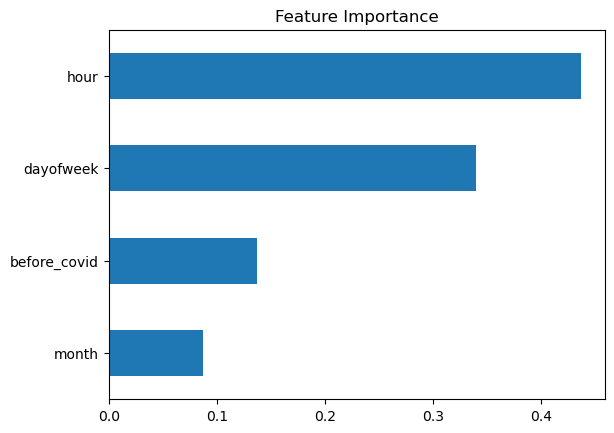

In [ ]:
importances = pd.Series(grid_search.best_estimator_.feature_importances_, index=x_train.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Use the best estimator from your GridSearch to make predictions
y_pred = grid_search.best_estimator_.predict(x_test)

# 2. Calculate standard regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance on Test Set ---")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}%")

--- Model Performance on Test Set ---
R-squared: 0.7167
Mean Absolute Error (MAE): 0.11%
Root Mean Squared Error (RMSE): 0.18%


Best Hyperparameters: {'ccp_alpha': np.float64(9.251313927791907e-05), 'min_samples_leaf': 5}
Tree Depth: 11
Number of Leaves: 35


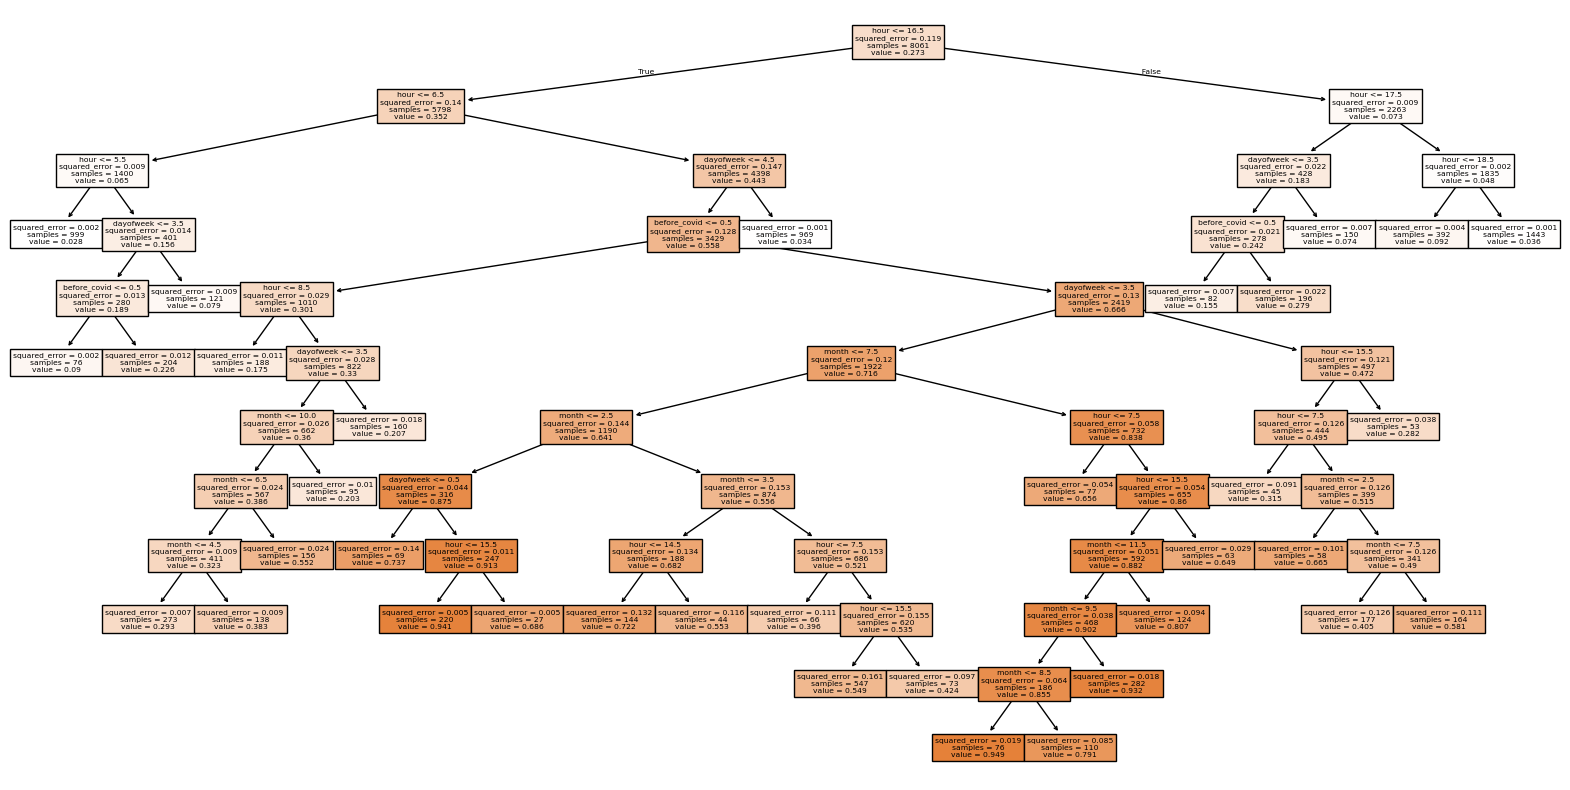

In [ ]:

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Tree Depth: {grid_search.best_estimator_.get_depth()}")
print(f"Number of Leaves: {grid_search.best_estimator_.get_n_leaves()}")
# Plot the actual tree
plt.figure(figsize=(20,10))
plot_tree(grid_search.best_estimator_, feature_names=x_train.columns, filled=True)
plt.show()

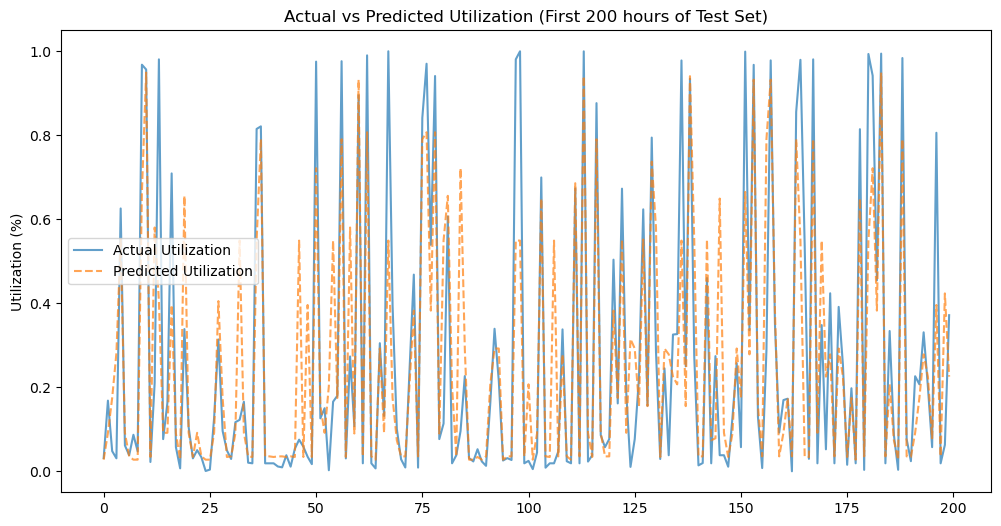

In [ ]:
# 3. Quick visualization: Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:200], label='Actual Utilization', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Utilization', alpha=0.7, linestyle='--')
plt.title('Actual vs Predicted Utilization (First 200 hours of Test Set)')
plt.ylabel('Utilization (%)')
plt.legend()
plt.show()

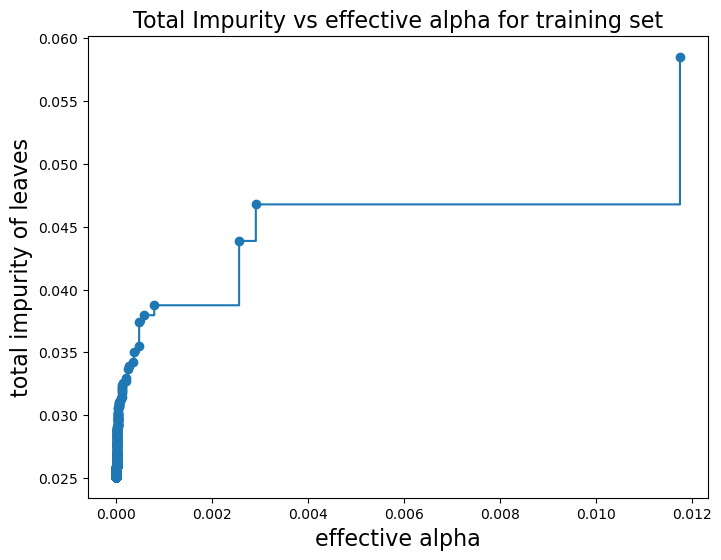

In [ ]:
# plot cost_complexity_pruning_path
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")  # we remove the last alpha as this corresponds to a tree with only the root node
ax.set_xlabel("effective alpha",fontsize=16)
ax.set_ylabel("total impurity of leaves",fontsize=16)
ax.set_title("Total Impurity vs effective alpha for training set",fontsize=16)
plt.show()

## NN

In [ ]:
# supress versioning warnings of keras
import warnings
warnings.filterwarnings('ignore')



In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [ ]:
import keras
from keras import Sequential, Input # sequential model: https://keras.io/guides/sequential_model/
from keras.layers import Dense, Dropout

OSError: [WinError 127] Die angegebene Prozedur wurde nicht gefunden. Error loading "c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

In [ ]:
X_nn = df_site_1_features[['hour', 'dayofweek', 'month', 'year']]#, 'util_last_hour_flag', 'util_prev_day_flag']]
y_nn = df_site_1_features['hourly_utilization']

In [ ]:
x_nn_train, x_nn_test, y_nn_train, y_nn_test = train_test_split(X_nn, y_nn, test_size=0.3, random_state=42)

In [ ]:
st_scaler = StandardScaler()
st_scaler.fit(x_nn_train)
x_nn_train_scaled = st_scaler.transform(x_nn_train)

In [ ]:
nn_model = Sequential()

nn_model.add(Input((4,)))

nn_model.add(Dense(64, activation=None))

nn_model.add(Dense(32, activation='relu'))

nn_model.add(Dense(1, activation=None))

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

In [ ]:
nn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 25
history = nn_model.fit(x_nn_train_scaled, y_nn_train,
                       epochs=epochs, validation_split=0.2)

Epoch 1/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0649 - mae: 0.1912 - mse: 0.0649 - val_loss: 0.0448 - val_mae: 0.1646 - val_mse: 0.0448
Epoch 2/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0410 - mae: 0.1550 - mse: 0.0410 - val_loss: 0.0387 - val_mae: 0.1461 - val_mse: 0.0387
Epoch 3/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.0366 - mae: 0.1430 - mse: 0.0366 - val_loss: 0.0345 - val_mae: 0.1387 - val_mse: 0.0345
Epoch 4/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0334 - mae: 0.1347 - mse: 0.0334 - val_loss: 0.0328 - val_mae: 0.1318 - val_mse: 0.0328
Epoch 5/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0314 - mae: 0.1291 - mse: 0.0314 - val_loss: 0.0316 - val_mae: 0.1275 - val_mse: 0.0316
Epoch 6/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0304 - mae: 0.1257 - mse: 0.0304 - val_loss: 0.0305 - val_mae: 0.1248 - val_mse: 0.0305
Epoch 7/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0297 - mae: 0.1242 - mse: 0.

In [ ]:
nn_model.predict(x_nn_train_scaled[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([[-0.05739661],
       [ 0.11160628],
       [ 0.25745335],
       [ 1.1012431 ],
       [-0.17619725],
       [ 0.6704559 ],
       [ 0.06278513],
       [ 0.93303764],
       [ 0.16833156],
       [ 0.8498376 ]], dtype=float32)

In [ ]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,0.064907,0.191158,0.064907,0.044789,0.164634,0.044789
1,0.040954,0.154963,0.040954,0.038728,0.146139,0.038728
2,0.036565,0.142968,0.036565,0.034537,0.138698,0.034537
3,0.033418,0.134656,0.033418,0.032837,0.131799,0.032837
4,0.031401,0.129050,0.031401,0.031635,0.127497,0.031635
5,0.030373,0.125739,0.030373,0.030499,0.124786,0.030499
6,0.029730,0.124216,0.029730,0.030659,0.124753,0.030659
7,0.028792,0.121869,0.028792,0.028632,0.118269,0.028632
8,0.027930,0.119195,0.027930,0.026970,0.115565,0.026970
9,0.026791,0.115976,0.026791,0.027164,0.114771,0.027164


In [ ]:
root_metrics_df = history_df[['mse', 'val_mse']].apply(np.sqrt)
root_metrics_df.rename({'mse': 'rmse', 'val_mse': 'val_rmse'}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,0.254769,0.211635
1,0.202371,0.196796
2,0.191219,0.185842
3,0.182805,0.181209
4,0.177204,0.177862
5,0.174278,0.174640
6,0.172424,0.175097
7,0.169681,0.169211
8,0.167123,0.164224
9,0.163679,0.164814


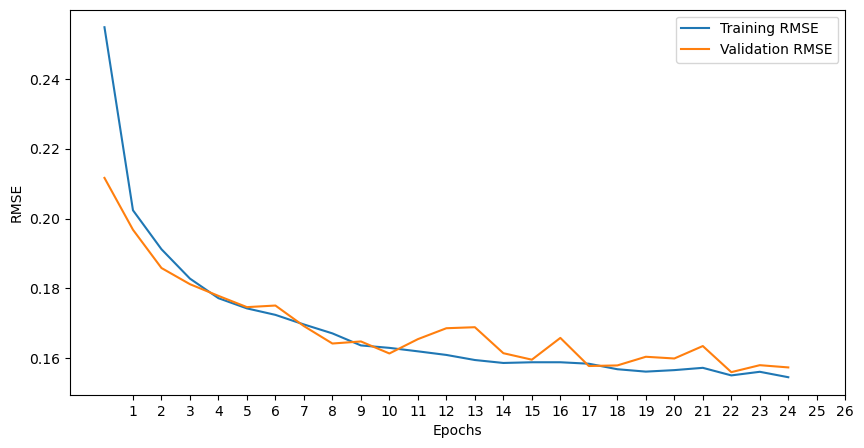

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(root_metrics_df['rmse'], label='Training RMSE')
plt.plot(root_metrics_df['val_rmse'], label='Validation RMSE')

plt.xlabel('Epochs')
plt.ylabel('RMSE')

plt.xticks(range(1, 27))
plt.legend()

plt.show()

In [ ]:
x_nn_test_scaled = st_scaler.transform(x_nn_test)
y_pred_nn = nn_model.predict(x_nn_test_scaled)

  1/152 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("--- Neural Network Model Performance on Test Set ---")
print(f"R-squared: {r2_score(y_nn_test, y_pred_nn):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_nn_test, y_pred_nn):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_nn_test, y_pred_nn)):.4f}")

--- Neural Network Model Performance on Test Set ---
R-squared: 0.7828
Mean Absolute Error (MAE): 0.1064
Root Mean Squared Error (RMSE): 0.1610


## c) Concrete Example of Application

TODO